# Visualize UMAP embeddings as scatterplots

## Import libraries

In [1]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(arrow))
suppressPackageStartupMessages(library(ggExtra))

Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘arrow’ was built under R version 4.2.3”


## Set up mapping for plate and output path

In [2]:
# Set up output directory for UMAP figures
dir.create("./figures", showWarnings = FALSE)

# Set directory and file structure
umap_dir <- "results"
umap_files <- list.files(umap_dir, full.names = TRUE)

output_fig_dir <- "figures"
plate_suffix <- ".parquet"

# Define output figure paths
output_umap_files <- setNames(
  file.path(
    output_fig_dir, 
    stringr::str_remove(basename(umap_files), plate_suffix) # Remove only .parquet
  ),
  basename(umap_files) # Use full original filenames as names
)

# Print the mapping in a cleaner format
cat("Mapping of input files to output paths:\n")
formatted_output <- data.frame(
  Original_File = basename(umap_files),
  Output_Path = file.path(output_fig_dir, stringr::str_remove(basename(umap_files), plate_suffix))
)
print(formatted_output, row.names = FALSE)

Mapping of input files to output paths:
                                                 Original_File
                UMAP_localhost220512140003_KK22-05-198.parquet
 UMAP_localhost220513100001_KK22-05-198_FactinAdjusted.parquet
                 UMAP_localhost230405150001_DMSO_drugx.parquet
                 UMAP_localhost230405150001_DMSO_TGFRi.parquet
                            UMAP_localhost230405150001.parquet
                            UMAP_localhost231120090001.parquet
                                                   Output_Path
                figures/UMAP_localhost220512140003_KK22-05-198
 figures/UMAP_localhost220513100001_KK22-05-198_FactinAdjusted
                 figures/UMAP_localhost230405150001_DMSO_drugx
                 figures/UMAP_localhost230405150001_DMSO_TGFRi
                            figures/UMAP_localhost230405150001
                            figures/UMAP_localhost231120090001


## Load in UMAP embeddings

In [3]:
# Load data
umap_cp_df <- list()

for (plate in names(output_umap_files)) {
    # Find the umap file associated with the plate
    umap_file <- umap_files[stringr::str_detect(umap_files, plate)]
    
    if (length(umap_file) > 0) {
        # Load the umap data directly from Parquet file
        df <- arrow::read_parquet(umap_file)
         
        # Group by Metadata_Well and count cells
        cell_count_df <- df %>%
            dplyr::group_by(Metadata_Well) %>%
            dplyr::count() %>%
            dplyr::rename(Metadata_Cell_Count = n)
        
        # Merge the cell count data with the original dataframe
        umap_cp_df[[plate]] <- df %>%
            dplyr::left_join(cell_count_df, by = "Metadata_Well")
            
    } else {
        message(paste("No file found for plate:", plate))
    }
}

# Inspect the first processed plate's data and print its dimensions
if (length(umap_cp_df) > 0) {
    plate_to_inspect <- names(umap_cp_df)[1]
    df_to_inspect <- umap_cp_df[[plate_to_inspect]]
    print(paste("Inspecting plate:", plate_to_inspect))
    print(paste("Dimensions:", dim(df_to_inspect)[1], "rows x", dim(df_to_inspect)[2], "columns"))
    head(df_to_inspect)
}

[1] "Inspecting plate: UMAP_localhost220512140003_KK22-05-198.parquet"
[1] "Dimensions: 30854 rows x 22 columns"


Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_treatment,Metadata_dose,Metadata_dose_unit,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,⋯,Metadata_Plate,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,UMAP0,UMAP1,Metadata_Cell_Count
<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<int>
A,1,3,drug_x,5,uM,220.49110,103.8781,238.99545,104.1795,⋯,localhost220512140003_KK22-05-198,A01,2,2,4,4,f00,-1.859528,2.2700589,353
A,1,3,drug_x,5,uM,77.76578,148.8271,92.41599,130.3018,⋯,localhost220512140003_KK22-05-198,A01,3,3,6,6,f00,-1.780111,2.6110473,353
A,1,3,drug_x,5,uM,180.30225,171.3147,199.19100,189.8277,⋯,localhost220512140003_KK22-05-198,A01,4,4,7,7,f00,1.320266,0.3857995,353
A,1,3,drug_x,5,uM,419.32820,196.2261,411.24057,178.8786,⋯,localhost220512140003_KK22-05-198,A01,5,5,8,8,f00,-1.677168,3.2080443,353
A,1,3,drug_x,5,uM,765.91288,208.3967,777.62108,212.2321,⋯,localhost220512140003_KK22-05-198,A01,6,6,9,9,f00,-1.374650,3.0139828,353
A,1,3,drug_x,5,uM,377.83268,247.4114,363.69958,247.4057,⋯,localhost220512140003_KK22-05-198,A01,7,7,10,10,f00,-1.229677,2.8916001,353


## Generate faceted dose UMAP for first two plates

The first two plates contain `KK22-05-198` within the filename.

In [4]:
# Filter for files with KK22-05-198 in the name
kk22_files <- umap_files[stringr::str_detect(umap_files, "KK22-05-198")]

# Get the corresponding plates from the output_umap_files
kk22_plates <- names(output_umap_files)[stringr::str_detect(names(output_umap_files), "KK22-05-198")]

for (plate in kk22_plates) {
    # Modify the Metadata_dose column to append 'uM' and preserve the order
    umap_cp_df[[plate]]$Metadata_dose <- paste0(umap_cp_df[[plate]]$Metadata_dose, " uM")
    
    # Remove " uM", sort the numeric values, and then append " uM" again
    sorted_doses <- sort(as.numeric(gsub(" uM", "", umap_cp_df[[plate]]$Metadata_dose)))
    
    # Ensure no duplicates and restore " uM"
    unique_sorted_doses <- unique(sorted_doses)
    umap_cp_df[[plate]]$Metadata_dose <- factor(
        umap_cp_df[[plate]]$Metadata_dose,
        levels = paste0(unique_sorted_doses, " uM")
    )
    
    # Dose UMAP
    output_file <- output_umap_files[[plate]]
    output_file <- paste0(output_file, "_dose_facet.png")
    
    umap_dose_gg <- (
        ggplot(umap_cp_df[[plate]], aes(x = UMAP0, y = UMAP1))
        + geom_point(
            aes(color = Metadata_Cell_Count), size = 0.4, alpha = 0.7
        )
        + theme_bw()
        + facet_wrap("~Metadata_dose")
        + theme(
            strip.background = element_rect(colour = "black", fill = "#fdfff4")
        )
        + scale_color_continuous(name = "Number of\nsingle cells\nper well", 
                             low = "lightblue", high = "darkblue")
    )
    
    ggsave(output_file, umap_dose_gg, dpi = 500, height = 6, width = 6)
}

## Generate UMAP for plate 3 data (all cells)

Plate 3 is also known as `localhost230405150001`.

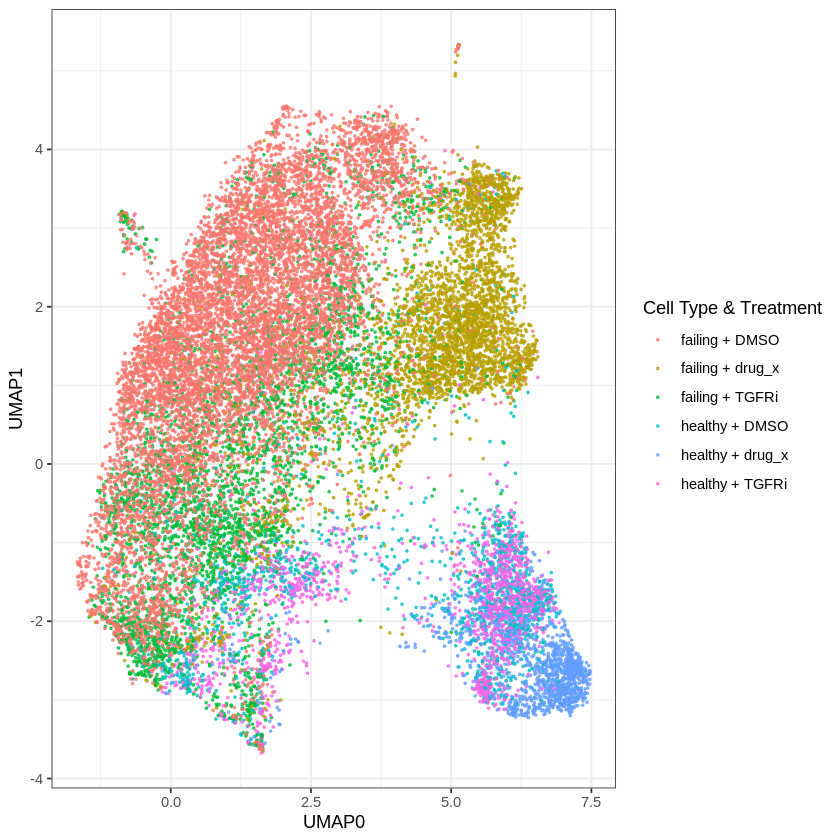

In [5]:
# Define the plate_id
plate_id <- "localhost230405150001"

# Construct the full file name by adding the UMAP prefix and .parquet suffix
plate_id_umap_file <- paste0("UMAP_", plate_id, ".parquet")

# Check if the plate_id_umap_file is present in umap_cp_df (considering the names might include additional details)
if (any(stringr::str_detect(names(umap_cp_df), plate_id_umap_file))) {
    # If the plate_id is found in umap_cp_df, extract the relevant plate data
    plate_data <- umap_cp_df[stringr::str_detect(names(umap_cp_df), plate_id_umap_file)][[1]]  # Access the first match if multiple

    # Create a new column combining cell type and treatment
    plate_data <- plate_data %>%
        dplyr::mutate(Group = paste(Metadata_cell_type, Metadata_treatment, sep = " + "))
    
    # Generate UMAP plot
    umap_combo_gg <- ggplot(plate_data, aes(x = UMAP0, y = UMAP1)) +
        geom_point(aes(color = Group), size = 0.4, alpha = 0.7) +
        theme_bw() +
        theme(
            strip.background = element_rect(color = "black", fill = "#fdfff4")
        ) +
        scale_color_discrete(name = "Cell Type & Treatment")
    
    # Save the plot
    output_file <- paste0(output_fig_dir, "/", "UMAP_", plate_id, "_all_cell_treatments.png")
    ggsave(output_file, umap_combo_gg, dpi = 500, height = 6, width = 8)
    
    # Print the plot
    print(umap_combo_gg)
} else {
    message(paste("No data found for plate:", plate_id))
}


## Generate UMAP for plate 3 (filtered cells)

There are two conditions for plate 3 where UMAP embeddings were fit on:

1. DMSO and TGFRi only
2. DMSO and drug_x only 

### DMSO and TGFRi only

We do not show the healthy TGFRi treated cells on this plot.

Warning message:
“Removed 1536 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1536 rows containing missing values or values outside the scale range
(`geom_line()`).”


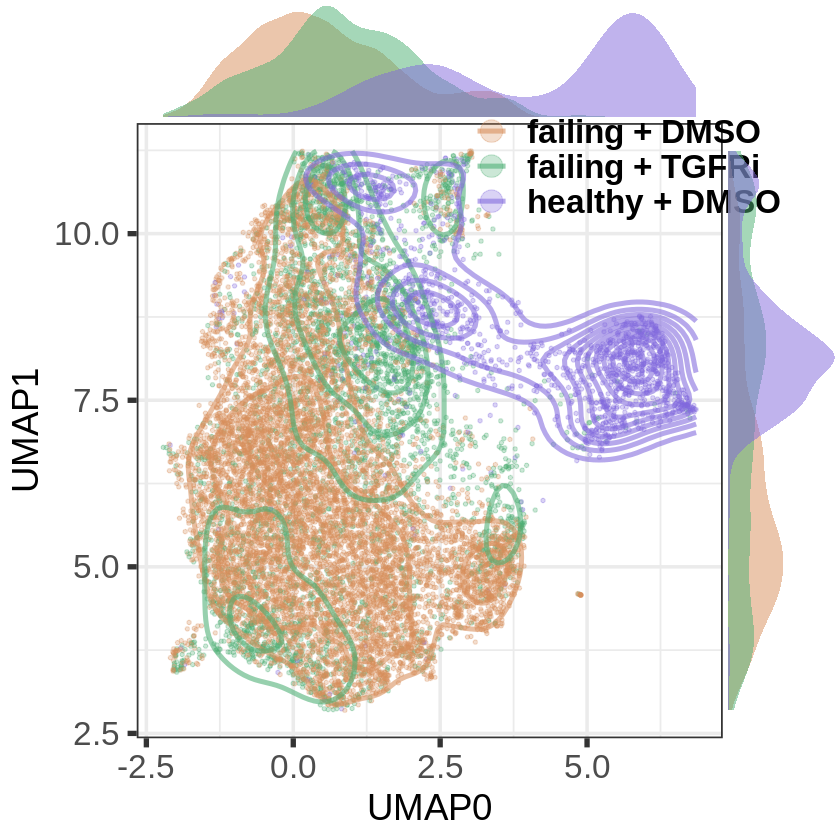

In [10]:
# Define the plate_id
plate_id <- "localhost230405150001_DMSO_TGFRi"

# Construct the full file name by adding the UMAP prefix and .parquet suffix
plate_id_umap_file <- paste0("UMAP_", plate_id, ".parquet")

# Check if the plate_id_umap_file is present in umap_cp_df (considering the names might include additional details)
if (any(stringr::str_detect(names(umap_cp_df), plate_id_umap_file))) {
    # If the plate_id is found in umap_cp_df, extract the relevant plate data
    plate_data <- umap_cp_df[stringr::str_detect(names(umap_cp_df), plate_id_umap_file)][[1]]  # Access the first match if multiple

    # Create a new column combining cell type and treatment
    plate_data <- plate_data %>%
        dplyr::mutate(Group = paste(Metadata_cell_type, Metadata_treatment, sep = " + "))
    
    # Filter for specific combinations: healthy + DMSO, failing + DMSO, and failing + TGFRi
    plate_data_filtered <- plate_data %>%
        dplyr::filter(
            (Metadata_cell_type == "healthy" & Metadata_treatment == "DMSO") |
            (Metadata_cell_type == "failing" & Metadata_treatment == "DMSO") |
            (Metadata_cell_type == "failing" & Metadata_treatment == "TGFRi")
        )
    
    # Create the main UMAP plot
    merged_TGFRi_plot <- ggplot(plate_data_filtered, aes(x = UMAP0, y = UMAP1)) +
    geom_point(size = 0.9, alpha = 0.29, aes(color = Group)) +
    geom_density_2d(aes(color = Group), alpha = 0.58, linewidth = 1.42) + # Adjust alpha and size as needed
    theme_bw(base_size = 22) +
    scale_color_manual(
        name = NA,
        values = c("failing + TGFRi" = "#4CAF73", "failing + DMSO" = "#D78E5A", "healthy + DMSO" = "#8269dc")
    ) +
    guides(color = guide_legend(override.aes = list(size = 6))) +
    ylim(min(plate_data$UMAP1), max(plate_data$UMAP1)) +
    theme(
        legend.position = c(0.84, 0.93),  # Move the legend to the top-right corner
        legend.background = element_blank(),  # Make legend background transparent
        legend.key = element_blank(),  # Remove the background from legend keys
        legend.title = element_blank(),  # Remove the legend title
        legend.text = element_text(size = 20, face = "bold"),  # Make legend text bigger and bold
        panel.background = element_rect(fill = "white"),  # White background inside the plot area
        plot.background = element_blank(),  # Make the outer area transparent
        axis.text = element_text(size = 20),  # Make axis text bigger
        axis.title = element_text(size = 22),  # Make axis titles bigger
        axis.ticks = element_line(linewidth = 1.5)  # Update to 'linewidth' instead of 'size'
    )

    # Add density plots in the margins
    merged_TGFRi_plot_with_margins <- ggMarginal(
        merged_TGFRi_plot,
        type = "density",  # Add density plots
        margins = "both",  # Add density plots to both x and y axes
        groupFill = TRUE,  # Use the group colors for the density plots
        linewidth = 5,  # Adjust the size of the marginal plots
        colour = NA  # Remove the outline around density plots
    )
    
    # Save as PNG
    output_png_file <- paste0(output_fig_dir, "/", "UMAP_", plate_id, "_without_healthy_TGFRi.png")
    ggsave(output_png_file, merged_TGFRi_plot_with_margins, dpi = 500, height = 12, width = 12)

    # Print the plot
    print(merged_TGFRi_plot_with_margins)
} else {
    message(paste("No data found for plate:", plate_id))
}

We include the healthy + TGFRi cells in grey in this plot.

Warning message:
“Removed 2048 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 2048 rows containing missing values or values outside the scale range
(`geom_line()`).”


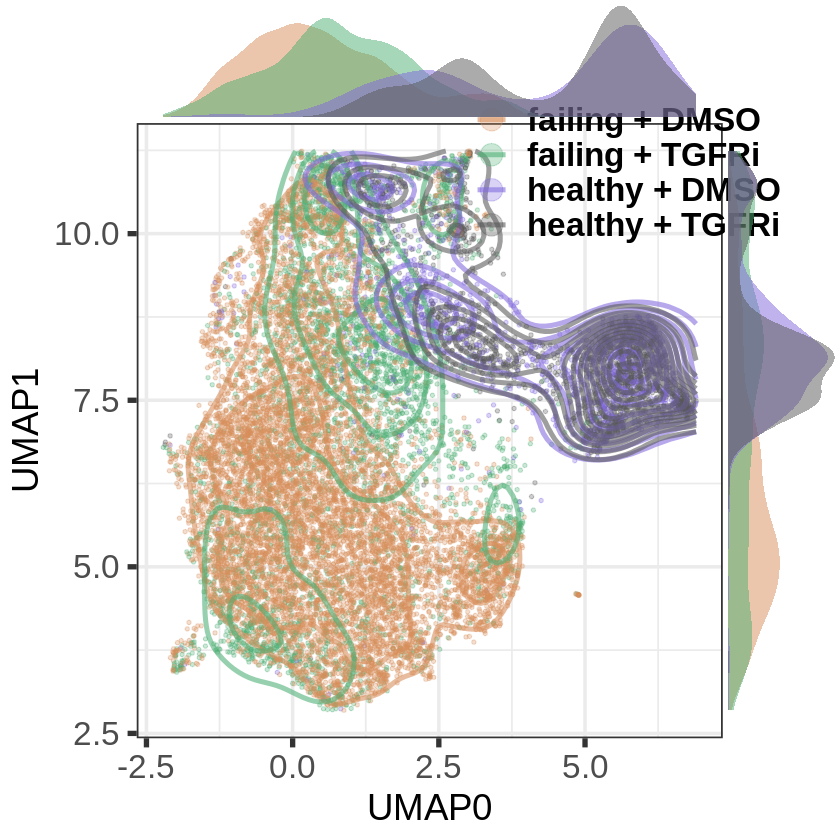

In [7]:
# Define the plate_id
plate_id <- "localhost230405150001_DMSO_TGFRi"

# Construct the full file name by adding the UMAP prefix and .parquet suffix
plate_id_umap_file <- paste0("UMAP_", plate_id, ".parquet")

# Check if the plate_id_umap_file is present in umap_cp_df (considering the names might include additional details)
if (any(stringr::str_detect(names(umap_cp_df), plate_id_umap_file))) {
    # If the plate_id is found in umap_cp_df, extract the relevant plate data
    plate_data <- umap_cp_df[stringr::str_detect(names(umap_cp_df), plate_id_umap_file)][[1]]  # Access the first match if multiple

    # Create a new column combining cell type and treatment
    plate_data <- plate_data %>%
        dplyr::mutate(Group = paste(Metadata_cell_type, Metadata_treatment, sep = " + "))
    
    # Create the main UMAP plot
    merged_TGFRi_plot <- ggplot(plate_data, aes(x = UMAP0, y = UMAP1)) +
    geom_point(size = 0.9, alpha = 0.29, aes(color = Group)) +
    geom_density_2d(aes(color = Group), alpha = 0.58, linewidth = 1.42) + # Adjust alpha and size as needed
    theme_bw(base_size = 22) +
    scale_color_manual(
        name = NA,
        values = c("failing + TGFRi" = "#4CAF73", "failing + DMSO" = "#D78E5A", "healthy + DMSO" = "#8269dc", "healthy + TGFRi" = "#595959")
    ) +
    guides(color = guide_legend(override.aes = list(size = 6))) +
    ylim(min(plate_data$UMAP1), max(plate_data$UMAP1)) +
    theme(
        legend.position = c(0.84, 0.92),  # Move the legend to the top-right corner
        legend.background = element_blank(),  # Make legend background transparent
        legend.key = element_blank(),  # Remove the background from legend keys
        legend.title = element_blank(),  # Remove the legend title
        legend.text = element_text(size = 20, face = "bold"),  # Make legend text bigger and bold
        panel.background = element_rect(fill = "white"),  # White background inside the plot area
        plot.background = element_blank(),  # Make the outer area transparent
        axis.text = element_text(size = 20),  # Make axis text bigger
        axis.title = element_text(size = 22),  # Make axis titles bigger
        axis.ticks = element_line(linewidth = 1.5)  # Update to 'linewidth' instead of 'size'
    )

    # Add density plots in the margins
    merged_TGFRi_plot_with_margins <- ggMarginal(
        merged_TGFRi_plot,
        type = "density",  # Add density plots
        margins = "both",  # Add density plots to both x and y axes
        groupFill = TRUE,  # Use the group colors for the density plots
        linewidth = 5,  # Adjust the size of the marginal plots
        colour = NA  # Remove the outline around density plots
    )
    
    # Save as PNG
    output_png_file <- paste0(output_fig_dir, "/", "UMAP_", plate_id, ".png")
    ggsave(output_png_file, merged_TGFRi_plot_with_margins, dpi = 500, height = 12, width = 12)

    # Save as PDF
    output_pdf_file <- paste0(output_fig_dir, "/", "UMAP_", plate_id, ".pdf")
    ggsave(output_pdf_file, merged_TGFRi_plot_with_margins, height = 12, width = 12)

    # Print the plot
    print(merged_TGFRi_plot_with_margins)
} else {
    message(paste("No data found for plate:", plate_id))
}

### DMSO and drug_x only

We do not show the healthy drug_x treated cells on this plot.

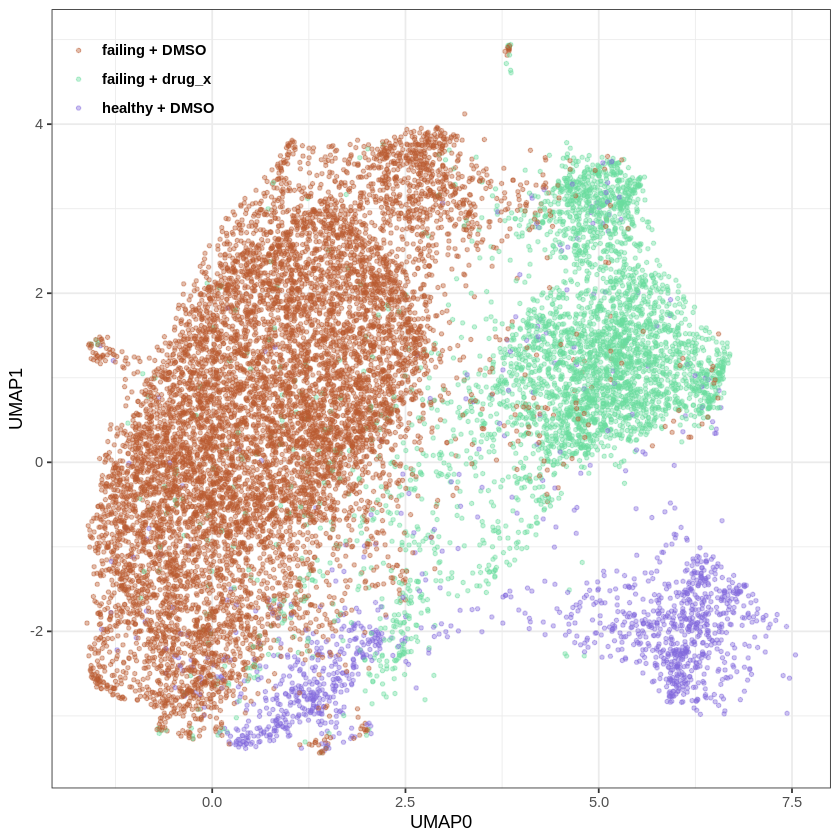

In [8]:
# Define the plate_id
plate_id <- "localhost230405150001_DMSO_drugx"

# Construct the full file name by adding the UMAP prefix and .parquet suffix
plate_id_umap_file <- paste0("UMAP_", plate_id, ".parquet")

# Check if the plate_id_umap_file is present in umap_cp_df (considering the names might include additional details)
if (any(stringr::str_detect(names(umap_cp_df), plate_id_umap_file))) {
    # If the plate_id is found in umap_cp_df, extract the relevant plate data
    plate_data <- umap_cp_df[stringr::str_detect(names(umap_cp_df), plate_id_umap_file)][[1]]  # Access the first match if multiple

    # Create a new column combining cell type and treatment
    plate_data <- plate_data %>%
        dplyr::mutate(Group = paste(Metadata_cell_type, Metadata_treatment, sep = " + "))
    
    # Filter for specific combinations: healthy + DMSO, failing + DMSO, and failing + drug_x
    plate_data_filtered <- plate_data %>%
        dplyr::filter(
            (Metadata_cell_type == "healthy" & Metadata_treatment == "DMSO") |
            (Metadata_cell_type == "failing" & Metadata_treatment == "DMSO") |
            (Metadata_cell_type == "failing" & Metadata_treatment == "drug_x")
        )
    
    # Generate UMAP plot
    umap_gg <- ggplot(plate_data_filtered, aes(x = UMAP0, y = UMAP1)) +
        geom_point(aes(color = Group), size = 0.9, alpha = 0.4) +
        theme_bw() +
        theme(
            strip.background = element_rect(color = "black", fill = "#fdfff4"),
            legend.position = c(0.11, 0.91),  # Move the legend inside, top left
            legend.background = element_blank(),  # Make legend background transparent
            legend.key = element_blank(),  # Remove the background from legend keys
            legend.title = element_blank(),  # Remove the legend title
            legend.text = element_text(
                face = "bold"),  # Make legend text bigger and bold
        ) +
        scale_color_manual(
            values = c("failing + drug_x" = "#69DC9E", "failing + DMSO" = "#BA5A31", "healthy + DMSO" = "#8269dc")
        )
    
    # Save the plot
    output_file <- paste0(output_fig_dir, "/", "UMAP_", plate_id, ".png")
    ggsave(output_file, umap_gg, dpi = 500, height = 6, width = 8)
    
    # Print the plot
    print(umap_gg)
} else {
    message(paste("No data found for plate:", plate_id))
}

## Generate UMAP for plate 4

Plate 4 is also known as `localhost231120090001`.

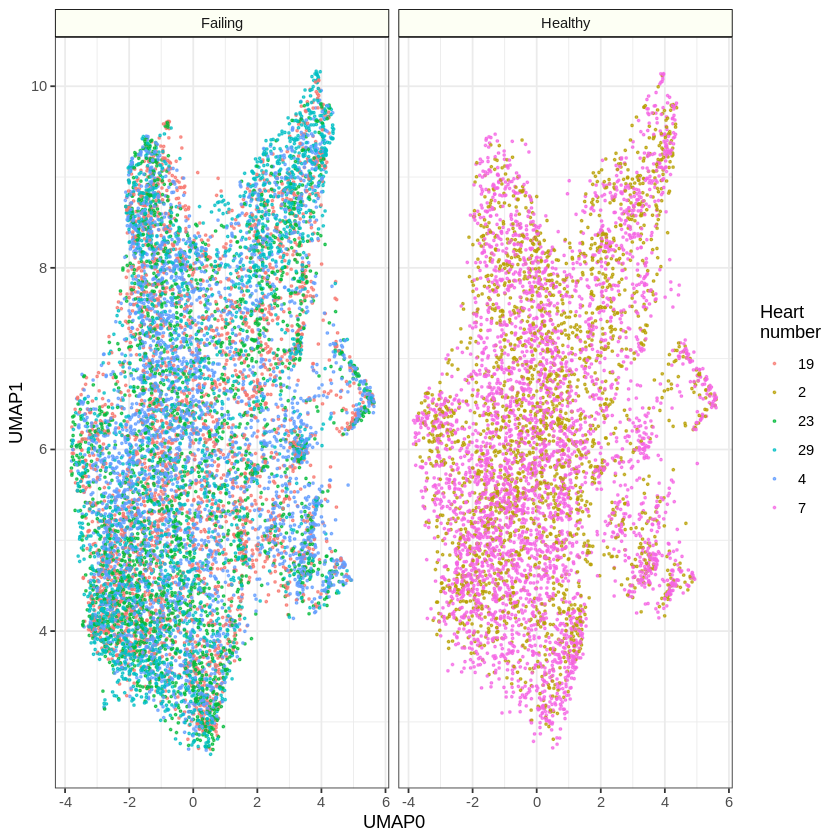

In [9]:
# Define the plate_id
plate_id <- "localhost231120090001"

# Construct the full file name by adding the UMAP prefix and .parquet suffix
plate_id_umap_file <- paste0("UMAP_", plate_id, ".parquet")

# Check if the plate_id_umap_file is present in umap_cp_df (considering the names might include additional details)
if (any(stringr::str_detect(names(umap_cp_df), plate_id_umap_file))) {
    # If the plate_id is found in umap_cp_df, extract the relevant plate data
    plate_data <- umap_cp_df[stringr::str_detect(names(umap_cp_df), plate_id_umap_file)][[1]]  # Access the first match if multiple

    # Convert Metadata_heart_number to a character
    plate_data$Metadata_heart_number <- as.character(plate_data$Metadata_heart_number)
    
    # Generate UMAP plot with facetting by Metadata_cell_type
    umap_heart_gg <- ggplot(plate_data, aes(x = UMAP0, y = UMAP1)) +
        geom_point(aes(color = Metadata_heart_number), size = 0.4, alpha = 0.7) +
        theme_bw() +
        theme(
            strip.background = element_rect(color = "black", fill = "#fdfff4")
        ) +
        scale_color_discrete(name = "Heart\nnumber") +
        facet_wrap(~Metadata_cell_type)  # Facet by Metadata_cell_type
    
    # Save the plot
    output_file <- paste0(output_fig_dir, "/", "UMAP_", plate_id, "_hearts.png")
    ggsave(output_file, umap_heart_gg, dpi = 500, height = 6, width = 8)
    
    # Print the plot
    print(umap_heart_gg)
} else {
    message(paste("No data found for plate:", plate_id))
}